# Ejercicio 5 — Incorporación de los datos de 2024

1. Se vuelve a ejecutar el script de descarga (que ahora usa `ANIOS_DEFAULT = (2024, 2026)`) para mostrar que no descarga nada que ya exista.
2. Se validan los archivos de 2024 con `sql/03_incorporacion_2024.sql` (V1–V6).
3. Se ejecutan **sin cambios** todas las consultas del Ejercicio 4 sobre 2024 + 2026 (punto 5.7).

Documentación: `docs/ejercicio5_incorporacion_2024.md`.

In [1]:
import os, subprocess, sys, time
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
sys.path.insert(0, "scripts")

import matplotlib.pyplot as plt
import pandas as pd
from lab_db import conectar, cargar_consultas

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 200)
con = conectar()
V = cargar_consultas("03_incorporacion_2024.sql")
COLORES = {2024: "#7B8FA1", 2026: "#C0392B"}

def q(nombre):
    return con.sql(V[nombre]).df()

## 5.3 / 5.4 — Ejecutar de nuevo la descarga

Los 40 archivos ya están en `data/raw/`, así que todos deben aparecer como *ya existe localmente*. Solo se consulta
al servidor por los meses de 2026 que aún no se publican. La salida de la primera ejecución (la que sí bajó 2024)
está en `docs/evidencia/ej5_descarga_2024.txt`.

In [2]:
salida = subprocess.run([sys.executable, "scripts/download_data.py"], capture_output=True, text=True).stdout
print(salida[salida.index("RESUMEN"):])

RESUMEN DE DESCARGA
  Anios          : 2024, 2026
  Descargados    : 0 (0.0 B)
  Ya existian    : 40
  No publicados  : 8
      yellow 2026-09, yellow 2026-10, yellow 2026-11, yellow 2026-12, green 2026-09, green 2026-10, green 2026-11, green 2026-12
  Fallidos       : 0



## 5.5 — Inventario de archivos (V1) y conteo por la vista (V2)

In [3]:
q("v1_inventario_archivos")

,tipo_taxi,anio,archivos,meses,registros_metadatos,mib
0,yellow,2024,12,"01,02,03,04,05,06,07,08,09,10,11,12",41169720.0,660.9
1,yellow,2026,8,"01,02,03,04,05,06,07,08",29703355.0,487.8
2,green,2024,12,"01,02,03,04,05,06,07,08,09,10,11,12",660218.0,15.2
3,green,2026,8,"01,02,03,04,05,06,07,08",337114.0,7.9


In [4]:
q("v2_conteo_vista_vs_metadatos")

,tipo_taxi,anio,meses,registros_metadatos,registros_vista,coincide
0,yellow,2024,12,41169720.0,41169720,True
1,yellow,2026,8,29703355.0,29703355,True
2,green,2024,12,660218.0,660218,True
3,green,2026,8,337114.0,337114,True


## Evolución del esquema (V3)

In [5]:
q("v3_evolucion_esquema")

,tipo_taxi,columna,archivos_con_columna,archivos_del_tipo,primer_periodo,ultimo_periodo,tipos_fisicos
0,yellow,cbd_congestion_fee,8,20,2026-01,2026-08,DOUBLE
1,yellow,request_source,3,20,2026-06,2026-08,BYTE_ARRAY
2,green,cbd_congestion_fee,8,20,2026-01,2026-08,DOUBLE
3,green,request_source,3,20,2026-06,2026-08,BYTE_ARRAY


## Calidad por año (V4)

In [6]:
q("v4_calidad_por_anio")

,tipo_taxi,anio,registros,r1_fuera_de_periodo,r2_duracion_invalida,r3_distancia_invalida,r4_monto_negativo,pct_excluidos,pct_passenger_nulo,pickup_min,pickup_max
0,yellow,2024,41169720,420,36884,777918,733885,3.60,9.94,2002-12-31 16:46:07,2026-06-26 23:53:12
1,yellow,2026,29703355,146,380268,953454,161970,4.94,25.98,2001-01-01 09:23:58,2026-08-31 23:59:59
2,green,2024,660218,164,3481,34809,2185,5.93,3.68,2008-12-31 00:00:00,2025-01-01 22:21:15
3,green,2026,337114,98,1453,12284,1025,4.19,14.47,2008-12-31 17:35:31,2026-08-31 23:58:28


## 5.6 — Consulta conjunta de 2024 y 2026 (V5, V6)

In [7]:
q("v5_comparacion_anual_ene_ago")

,tipo_taxi,anio,viajes,viajes_por_dia,mediana_distancia_mi,mediana_duracion_min,mediana_total,pct_tarjeta,pct_efectivo,pct_pago_no_registrado,pct_con_cargo_cbd
0,yellow,2024,25499838,104508.0,1.80,12.7,21.00,75.9,13.8,9.0,0.0
1,yellow,2026,28234916,116193.0,1.93,14.1,23.58,65.4,9.1,25.0,72.4
2,green,2024,416991,1709.0,1.96,11.8,19.14,67.8,27.7,4.0,0.0
3,green,2026,322984,1329.0,2.14,13.3,20.52,65.5,19.4,14.8,8.5


,tipo_taxi,mes,por_dia_2024,por_dia_2026,variacion_pct
0,yellow,1,92519.0,113440.0,22.6
1,yellow,2,99998.0,114657.0,14.7
2,yellow,3,110918.0,121396.0,9.4
3,yellow,4,113754.0,122490.0,7.7
4,yellow,5,116648.0,126211.0,8.2
5,yellow,6,114220.0,121562.0,6.4
6,yellow,7,95881.0,107957.0,12.6
7,yellow,8,92443.0,102059.0,10.4
8,yellow,9,116086.0,NaN,NaN
9,yellow,10,118723.0,NaN,NaN


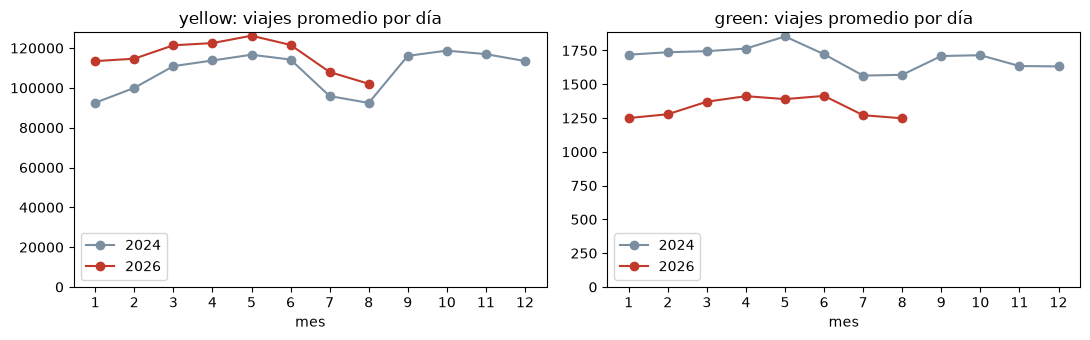

In [8]:
v6 = q("v6_viajes_por_dia_mes_anio")
fig, ejes = plt.subplots(1, 2, figsize=(11, 3.5))
for eje, tipo in zip(ejes, ["yellow", "green"]):
    d = v6[v6.tipo_taxi == tipo]
    eje.plot(d.mes, d.por_dia_2024, marker="o", label="2024", color=COLORES[2024])
    eje.plot(d.mes, d.por_dia_2026, marker="o", label="2026", color=COLORES[2026])
    eje.set_title(f"{tipo}: viajes promedio por día"); eje.set_xticks(range(1, 13))
    eje.set_xlabel("mes"); eje.set_ylim(0, None); eje.legend()
fig.tight_layout(); fig.savefig("docs/img/ej5_viajes_por_dia_2024_2026.png", dpi=110)
v6

## 5.7 — ¿Las consultas anteriores deben modificarse?

Se ejecutan todas las consultas de `sql/02_analisis_exploratorio.sql` tal como están, ahora sobre 2024 + 2026,
y se registra si producen resultados y si separan los años (`anio` en el resultado).

In [9]:
filas = []
for nombre, sql in cargar_consultas("02_analisis_exploratorio.sql").items():
    inicio = time.perf_counter()
    try:
        df = con.sql(sql).df()
        estado, n, por_anio = "OK", len(df), "anio" in df.columns
    except Exception as error:          # se registra cualquier fallo en lugar de detener el notebook
        estado, n, por_anio = f"ERROR: {error}", None, None
    filas.append({"consulta": nombre, "estado": estado, "filas": n, "separa_anios": por_anio,
                  "segundos": round(time.perf_counter() - inicio, 2)})
pd.DataFrame(filas)

,consulta,estado,filas,separa_anios,segundos
0,p1_viajes_por_mes,OK,40,True,1.17
1,p2_hora_dia_semana,OK,336,False,1.22
2,p3_caracteristicas_viaje,OK,2,False,10.25
3,p4_velocidad_por_hora,OK,48,False,2.82
4,p5a_borough_origen,OK,16,False,1.34
5,p5b_top_zonas_origen,OK,20,False,1.49
6,p6_aeropuertos,OK,2,False,1.65
7,p7_metodo_pago,OK,213,True,0.35
8,p8a_propinas_por_metodo,OK,4,False,1.98
9,p8b_histograma_pct_propina,OK,82,False,1.21


In [10]:
# Ejemplo: P1 ahora devuelve 2024 y 2026 sin ningun cambio en el SQL.
con.sql(cargar_consultas("02_analisis_exploratorio.sql")["p1_viajes_por_mes"]).df().query("tipo_taxi == 'green'")

,tipo_taxi,anio,mes,viajes,viajes_por_dia
0,green,2024,1,53304,1719.0
1,green,2024,2,50387,1737.0
2,green,2024,3,54090,1745.0
3,green,2024,4,52930,1764.0
4,green,2024,5,57469,1854.0
5,green,2024,6,51668,1722.0
6,green,2024,7,48479,1564.0
7,green,2024,8,48664,1570.0
8,green,2024,9,51279,1709.0
9,green,2024,10,53173,1715.0


Las consultas del Ejercicio 3 (`sql/01_exploracion_parquet.sql`) **sí** tienen rutas fijas a `data/raw/<tipo>/2026/`.
No fallan, pero solo describen 2026. Fueron diseñadas para explorar ese año y por eso no se cambiaron; para el
análisis conjunto se usan las vistas.